# SecureProBot: An Adversarially Resilient Random Forest Model for Robust Twitter Bot Detection Using Profile Metadata


### Architecture Overview
SecureProBot implements a **hybrid deep learning + ensemble machine learning pipeline**:

| Stage | Component | Input | Output | Purpose |
|-------|-----------|-------|--------|----------|
| 1 | Text Embedding | Raw tweets | 50-dim GloVe | Semantic representation |
| 2 | LSTM(32) → LSTM(32) | Embedded sequences | 32-dim vector | Deep temporal feature extraction |
| 3 | Metadata Features | User profile data | 23-dim vector | Domain-specific signals |
| 4 | Concatenation | Both streams | 55-dim vector | Combined representation |
| 5 | Ensemble (RF + ET) | 55-dim features | Bot probability | Robust classification |
| 6 | Soft Voting | RF & ET predictions | Final score | Adversarial robustness |

### Key Features
✓ **Data Leakage Prevention**: 75/12.5/12.5 split with strict fit/transform boundaries  
✓ **Adversarial Robustness**: ε=0.1 noise augmentation on bot samples  
✓ **Domain Adaptation**: Cross-domain testing on 4 independent datasets  
✓ **Class Balancing**: Per-dataset downsampling + domain weighting  
✓ **Comprehensive Evaluation**: 7 visualization plots + cross-validation

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, accuracy_score, auc, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow: {tf.__version__}\nPandas: {pd.__version__}\nNumPy: {np.__version__}")

MAX_VOCAB, MAX_LEN, EMBEDDING_DIM = 10_000, 30, 50
BATCH_SIZE, EPOCHS, RANDOM_SEED = 40, 25, 42
EPSILON, LSTM_FRAC, RF_FRAC, VAL_FRAC = 0.1, 0.75, 0.125, 0.125
DATA_DIR, GLOVE_PATH = "./", "./glove.twitter.27B.50d.txt"
LOCAL_DATA_DIR = "./"

BALANCE_PER_DATASET = True
INCLUDE_SINGLE_CLASS_TRAIN = True
STRATIFY_SPLIT = True

METADATA_COLS = [
    'statuses_count', 'followers_count', 'friends_count', 'favourites_count',
    'listed_count', 'verified', 'description_length', 'description_entropy',
    'screen_name_entropy', 'tweet_freq', 'followers_friends_ratio', 'has_description',
    'user_age', 'followers_growth_rate', 'friends_growth_rate',
    'favourites_growth_rate', 'listed_growth_rate',
    'name_entropy', 'num_digits_in_name', 'num_digits_in_screen_name',
    'screen_name_freq', 'name_sim', 'default_profile',
]
ADVERS_FEATURES = ["followers_count", "statuses_count", "favourites_count", "description_entropy"]

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print(f"\n=== CONFIG ===")
print(f"Vocab: {MAX_VOCAB} | Seq len: {MAX_LEN} | Embed dim: {EMBEDDING_DIM}")
print(f"Batch: {BATCH_SIZE} | Epochs: {EPOCHS} | Splits: {LSTM_FRAC*100:.0f}% LSTM / {RF_FRAC*100:.1f}% RF / {VAL_FRAC*100:.1f}% VAL")
print(f"Adversarial epsilon: {EPSILON} | Seed: {RANDOM_SEED}")

TensorFlow: 2.21.0
Pandas: 3.0.3
NumPy: 2.4.5

=== CONFIG ===
Vocab: 10000 | Seq len: 30 | Embed dim: 50
Batch: 40 | Epochs: 25 | Splits: 75% LSTM / 12.5% RF / 12.5% VAL
Adversarial epsilon: 0.1 | Seed: 42


## 1. Data Loading & Balancing

In [3]:
def find_label_col(df):
    for col in ['label', 'bot', 'is_bot', 'class', 'target', 'is_bot_label']:
        if col in df.columns:
            return col
    raise ValueError(f"Label column not found. Available: {df.columns.tolist()}")

def standardize_label(series, dataset_name=''):
    """Robust label standardization with dataset-specific overrides."""
    s = series.copy()
    
    # Handle string labels
    if s.dtype == object:
        s_lower = s.astype(str).str.lower().str.strip()
        # Bot = 1, Human = 0
        bot_vals = {'bot', '1', 'true', 'yes', 'spam', 'spambot', 'fake'}
        human_vals = {'human', '0', 'false', 'no', 'genuine', 'real', 'verified'}
        
        result = pd.Series(index=s.index, dtype=float)
        result[s_lower.isin(bot_vals)] = 1
        result[s_lower.isin(human_vals)] = 0
        # If ambiguous, use numeric fallback
        ambiguous = result.isna()
        result[ambiguous] = pd.to_numeric(s[ambiguous], errors='coerce').fillna(0) > 0
        return result.astype(int)
    
    # Numeric: check if values are 0/1 or need inversion
    numeric = pd.to_numeric(s, errors='coerce').fillna(0)
    
    # varol-icwsm specific: label 0=bot, 1=human (inverted!)
    if 'varol' in dataset_name.lower():
        return (numeric == 0).astype(int)   # flip: 0→bot(1), 1→human(0)
    
    return (numeric > 0).astype(int)

def balance_dataset(df, random_state=RANDOM_SEED):
    """Balance dataset by downsampling majority class to match minority"""
    label_col = find_label_col(df)
    y = df[label_col]
    
    # Get indices for each class
    class_1_idx = y[y == 1].index
    class_0_idx = y[y == 0].index
    
    n_class_1 = len(class_1_idx)
    n_class_0 = len(class_0_idx)
    
    # If either class is empty, return as-is
    if n_class_1 == 0 or n_class_0 == 0:
        return df
    
    # Determine minority and majority
    if n_class_1 < n_class_0:
        minority_idx = class_1_idx
        majority_idx = class_0_idx
    else:
        minority_idx = class_0_idx
        majority_idx = class_1_idx
    
    n_minority = len(minority_idx)
    n_majority = len(majority_idx)
    
    # If already balanced or close to it, don't oversample
    if n_minority == 0:
        return df
    
    # Downsample majority to match minority
    if n_majority > n_minority:
        majority_downsampled = np.random.RandomState(random_state).choice(majority_idx, size=n_minority, replace=False)
        balanced_idx = np.concatenate([minority_idx, majority_downsampled])
    else:
        balanced_idx = np.concatenate([minority_idx, majority_idx])
    
    return df.loc[balanced_idx].reset_index(drop=True)

datasets_to_load = [
    ("varol-icwsm.csv", "varol"),
    ("cresci-2017.csv", "cresci_17"),
    ("celebrity.csv", "celebrity"),
    ("botometer-feedback-2019.csv", "feedback"),
    ("political-bots.csv", "political"),
]

all_dfs, dataset_info = [], []
for filename, short_name in datasets_to_load:
    filepath = os.path.join(LOCAL_DATA_DIR, filename)
    if not os.path.exists(filepath):
        print(f"⚠️ {filename} not found")
        continue
    try:
        df = pd.read_csv(filepath)
        label_col = find_label_col(df)
        df['label'] = standardize_label(df[label_col], dataset_name=short_name)
        df['source'] = short_name
        
        n_bots = (df['label'] == 1).sum()
        n_humans = (df['label'] == 0).sum()
        if not INCLUDE_SINGLE_CLASS_TRAIN and (n_bots == 0 or n_humans == 0):
            print(f"⚠️ {filename}: Single-class (Bots: {n_bots}, Humans: {n_humans}) - skipped")
            continue
        
        df_balanced = balance_dataset(df) if BALANCE_PER_DATASET else df
        
        if len(df_balanced) == 0:
            print(f"⚠️ {filename}: Empty after balancing")
            continue
        
        all_dfs.append(df_balanced)
        n_bots = (df_balanced['label'] == 1).sum()
        n_humans = (df_balanced['label'] == 0).sum()
        dataset_info.append({
            'dataset': filename.replace('.csv', ''),
            'total': len(df_balanced),
            'bots': n_bots,
            'humans': n_humans
        })
        print(f"✓ {filename}: {len(df_balanced)} samples (Bots: {n_bots}, Humans: {n_humans})")
    except Exception as e:
        print(f"✗ {filename}: {str(e)}")

if all_dfs:
    train_df = pd.concat(all_dfs, ignore_index=True)
    print(f"\n✓ Combined: {train_df.shape}")
else:
    train_df = pd.DataFrame()
    print("ERROR: No datasets loaded")

✓ varol-icwsm.csv: 2572 samples (Bots: 2572, Humans: 0)
✓ cresci-2017.csv: 6948 samples (Bots: 3474, Humans: 3474)
✓ celebrity.csv: 20983 samples (Bots: 0, Humans: 20983)
✓ botometer-feedback-2019.csv: 518 samples (Bots: 518, Humans: 0)
✓ political-bots.csv: 62 samples (Bots: 62, Humans: 0)

✓ Combined: (31083, 14)


## 2. Dataset Diagnostics

In [4]:
if len(dataset_info) > 0:
    diagnostic_df = pd.DataFrame(dataset_info)
    diagnostic_df['ratio'] = diagnostic_df['bots'] / diagnostic_df['total']
    print("\n" + "="*70)
    print("DATASET COMPOSITION")
    print("="*70)
    print(diagnostic_df.to_string(index=False))
    total_samples = diagnostic_df['total'].sum()
    total_bots = diagnostic_df['bots'].sum()
    print(f"\nTOTAL: {total_samples} | Bots: {total_bots} ({total_bots/total_samples*100:.2f}%)")
    print("="*70)
else:
    print("⚠️ No datasets loaded")


DATASET COMPOSITION
                dataset  total  bots  humans  ratio
            varol-icwsm   2572  2572       0    1.0
            cresci-2017   6948  3474    3474    0.5
              celebrity  20983     0   20983    0.0
botometer-feedback-2019    518   518       0    1.0
         political-bots     62    62       0    1.0

TOTAL: 31083 | Bots: 6626 (21.32%)


## 3. Feature Engineering

In [5]:
def calculate_entropy(text):
    if not isinstance(text, str) or len(text) == 0:
        return 0.0
    from collections import Counter
    counts = Counter(text)
    probs = np.array(list(counts.values())) / len(text)
    entropy = -np.sum(probs * np.log2(probs + 1e-10))
    max_entropy = np.log2(len(counts))
    return entropy / max_entropy if max_entropy > 0 else 0.0

def clean_text(text):
    if not isinstance(text, str):
        return ""
    import re
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|@\w+|#\w+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def get_derived_features(df):
    df_feat = df.copy()
    for feat in ['statuses_count', 'followers_count', 'friends_count', 'favourites_count', 'listed_count', 'verified']:
        df_feat[feat] = pd.to_numeric(df_feat.get(feat, 0), errors='coerce').fillna(0)
    
    # Account age in days
    if 'created_at' in df_feat.columns:
        try:
            created = pd.to_datetime(df_feat['created_at'], errors='coerce', utc=True)
            now = pd.Timestamp.now(tz='UTC')
            df_feat['user_age'] = (now - created).dt.days.fillna(365)
        except Exception:
            df_feat['user_age'] = 365
    else:
        df_feat['user_age'] = 365
    df_feat['user_age'] = pd.to_numeric(df_feat['user_age'], errors='coerce').fillna(365).clip(lower=1)
    
    # Growth rate features
    df_feat['followers_growth_rate'] = df_feat['followers_count'] / df_feat['user_age']
    df_feat['friends_growth_rate'] = df_feat['friends_count'] / df_feat['user_age']
    df_feat['favourites_growth_rate'] = df_feat['favourites_count'] / df_feat['user_age']
    df_feat['listed_growth_rate'] = df_feat['listed_count'] / df_feat['user_age']
    
    # Name-based features
    if 'name' in df_feat.columns:
        df_feat['name'] = df_feat['name'].fillna('').astype(str)
    else:
        df_feat['name'] = ''
    df_feat['name_entropy'] = df_feat['name'].apply(calculate_entropy)
    df_feat['num_digits_in_name'] = df_feat['name'].apply(lambda x: sum(c.isdigit() for c in str(x)))
    
    if 'screen_name' in df_feat.columns:
        df_feat['screen_name'] = df_feat['screen_name'].fillna('').astype(str)
    else:
        df_feat['screen_name'] = ''
    df_feat['num_digits_in_screen_name'] = df_feat['screen_name'].apply(lambda x: sum(c.isdigit() for c in str(x)))
    
    # Screen name bigram frequency (mean character bigram frequency)
    def bigram_freq(s):
        s = str(s)
        if len(s) < 2:
            return 0.0
        bigrams = [s[i:i+2] for i in range(len(s)-1)]
        from collections import Counter
        counts = Counter(bigrams)
        return sum(counts.values()) / len(counts)
    df_feat['screen_name_freq'] = df_feat['screen_name'].apply(bigram_freq)
    
    # Name similarity between screen_name and display name
    def name_sim(row):
        sn = str(row.get('screen_name', '')).lower()
        n = str(row.get('name', '')).lower().replace(' ', '')
        if not sn or not n:
            return 0.0
        matches = sum(c in n for c in sn)
        return 2 * matches / (len(sn) + len(n)) if (len(sn) + len(n)) > 0 else 0.0
    df_feat['name_sim'] = df_feat.apply(name_sim, axis=1)
    
    # Default profile (binary)
    if 'default_profile' in df_feat.columns:
        df_feat['default_profile'] = df_feat['default_profile'].fillna(True)
        df_feat['default_profile'] = df_feat['default_profile'].apply(
            lambda x: 1 if str(x).lower() in ['true', '1', 'yes'] else 0)
    else:
        df_feat['default_profile'] = 0
    
    desc_col = next((c for c in df_feat.columns if 'description' in c.lower() or 'bio' in c.lower()), None)
    if desc_col:
        df_feat['description_length'] = df_feat[desc_col].fillna('').astype(str).str.len()
        df_feat['description_entropy'] = df_feat[desc_col].fillna('').apply(calculate_entropy)
        df_feat['has_description'] = (df_feat['description_length'] > 0).astype(int)
    else:
        df_feat['description_length'] = 0
        df_feat['description_entropy'] = 0.0
        df_feat['has_description'] = 0
    
    screen_col = next((c for c in df_feat.columns if 'screen_name' in c.lower() or 'username' in c.lower()), None)
    df_feat['screen_name_entropy'] = df_feat[screen_col].fillna('').astype(str).apply(calculate_entropy) if screen_col else 0.0
    
    df_feat['tweet_freq'] = df_feat['statuses_count'] / 365.0
    df_feat['followers_friends_ratio'] = np.where(df_feat['friends_count'] > 0, df_feat['followers_count'] / df_feat['friends_count'], 0)
    
    for col in METADATA_COLS:
        if col not in df_feat.columns:
            df_feat[col] = 0
    
    df_feat = df_feat.replace([np.inf, -np.inf], 0)
    return df_feat

if len(train_df) > 0:
    print("Applying feature engineering...")
    train_df = get_derived_features(train_df)
    print(f"✓ Complete. Shape: {train_df.shape}")
    print(f"\nMetadata features:")
    print(train_df[METADATA_COLS].describe())
else:
    print("⚠️ No data")

Applying feature engineering...


✓ Complete. Shape: (31083, 30)

Metadata features:
       statuses_count  followers_count  friends_count  favourites_count  \
count    3.108300e+04     3.108300e+04   3.108300e+04      31083.000000   
mean     2.707094e+04     6.776561e+05   6.716273e+03       3700.382556   
std      1.418582e+05     2.781506e+06   5.713133e+04      13187.966307   
min      0.000000e+00     0.000000e+00   0.000000e+00          0.000000   
25%      7.430000e+02     3.510000e+02   8.500000e+01          7.000000   
50%      6.188000e+03     2.849000e+04   3.660000e+02        529.000000   
75%      2.024800e+04     4.113635e+05   1.110000e+03       2951.000000   
max      1.615822e+07     1.089908e+08   4.458422e+06     910116.000000   

       listed_count      verified  description_length  description_entropy  \
count  3.108300e+04  31083.000000        31083.000000         31083.000000   
mean   1.932259e+03      0.432487           80.428144             0.746854   
std    1.975921e+04      0.495429     

## 4. Data Split 

In [6]:
if len(train_df) > 0:
    n_samples = len(train_df)
    y_all = train_df['label'].values
    indices = np.arange(n_samples)
    rng = np.random.RandomState(RANDOM_SEED)
    
    if STRATIFY_SPLIT:
        lstm_idx, rf_idx, val_idx = [], [], []
        for label in [0, 1]:
            label_idx = indices[y_all == label]
            rng.shuffle(label_idx)
            n_label = len(label_idx)
            n_lstm = int(n_label * LSTM_FRAC)
            n_rf = int(n_label * RF_FRAC)
            n_val = n_label - n_lstm - n_rf
            lstm_idx.append(label_idx[:n_lstm])
            rf_idx.append(label_idx[n_lstm:n_lstm + n_rf])
            val_idx.append(label_idx[n_lstm + n_rf:])
        lstm_idx = np.concatenate(lstm_idx)
        rf_idx = np.concatenate(rf_idx)
        val_idx = np.concatenate(val_idx)
        rng.shuffle(lstm_idx)
        rng.shuffle(rf_idx)
        rng.shuffle(val_idx)
    else:
        rng.shuffle(indices)
        n_lstm = int(n_samples * LSTM_FRAC)
        n_rf = int(n_samples * RF_FRAC)
        lstm_idx = indices[:n_lstm]
        rf_idx = indices[n_lstm:n_lstm + n_rf]
        val_idx = indices[n_lstm + n_rf:]
    
    assert len(set(lstm_idx) & set(rf_idx)) == 0
    assert len(set(lstm_idx) & set(val_idx)) == 0
    assert len(set(rf_idx) & set(val_idx)) == 0
    
    X_lstm = train_df.iloc[lstm_idx].copy()
    X_rf = train_df.iloc[rf_idx].copy()
    X_val = train_df.iloc[val_idx].copy()
    
    y_lstm, y_rf, y_val = X_lstm['label'].values, X_rf['label'].values, X_val['label'].values
    
    print("\n" + "="*70)
    print("3-WAY SPLIT")
    print("="*70)
    print(f"LSTM:       {len(X_lstm):,} ({len(X_lstm)/n_samples*100:.1f}%) | Bots: {(y_lstm==1).sum()} | Ratio: {y_lstm.mean():.4f}")
    print(f"RF:         {len(X_rf):,} ({len(X_rf)/n_samples*100:.1f}%) | Bots: {(y_rf==1).sum()} | Ratio: {y_rf.mean():.4f}")
    print(f"VALIDATION: {len(X_val):,} ({len(X_val)/n_samples*100:.1f}%) | Bots: {(y_val==1).sum()} | Ratio: {y_val.mean():.4f}")
    print(f"Leakage Check: ✓ No overlap")
    print("="*70)
else:
    print("⚠️ No data to split")


3-WAY SPLIT
LSTM:       23,311 (75.0%) | Bots: 4969 | Ratio: 0.2132
RF:         3,885 (12.5%) | Bots: 828 | Ratio: 0.2131
VALIDATION: 3,887 (12.5%) | Bots: 829 | Ratio: 0.2133
Leakage Check: ✓ No overlap


## 5. Text Preprocessing & GloVe

In [7]:
if len(train_df) > 0:
    # Priority: description (bio) > screen_name > name > any text column > any object column
    text_col = next((c for c in train_df.columns if any(k in c.lower() for k in ['text', 'tweet', 'content', 'description', 'bio'])), None)
    if text_col is None:
        text_col = next((c for c in train_df.columns if any(k in c.lower() for k in ['screen_name', 'username'])), None)
    if text_col is None:
        text_col = next((c for c in train_df.columns if any(k in c.lower() for k in ['name'])), None)
    if text_col is None:
        text_col = next((c for c in train_df.columns if train_df[c].dtype == 'object'), None)
    
    if text_col is None:
        raise ValueError("No text column found for modeling.")
    
    print(f"Text column: '{text_col}'")
    tweets_lstm = X_lstm[text_col].fillna('').astype(str).apply(clean_text).tolist()
    tweets_rf = X_rf[text_col].fillna('').astype(str).apply(clean_text).tolist()
    tweets_val = X_val[text_col].fillna('').astype(str).apply(clean_text).tolist()
    
    tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
    tokenizer.fit_on_texts(tweets_lstm)
    print(f"✓ Tokenizer fit on {len(tweets_lstm)} LSTM texts")
    print(f"  Vocab: {len(tokenizer.word_index)}")
    
    X_lstm_text = pad_sequences(tokenizer.texts_to_sequences(tweets_lstm), maxlen=MAX_LEN, padding='post')
    X_rf_text = pad_sequences(tokenizer.texts_to_sequences(tweets_rf), maxlen=MAX_LEN, padding='post')
    X_val_text = pad_sequences(tokenizer.texts_to_sequences(tweets_val), maxlen=MAX_LEN, padding='post')
    print(f"\n✓ Sequences padded to {MAX_LEN}")
    print(f"  LSTM: {X_lstm_text.shape} | RF: {X_rf_text.shape} | VAL: {X_val_text.shape}")
else:
    print("⚠️ No data")

Text column: 'description'
✓ Tokenizer fit on 23311 LSTM texts
  Vocab: 43349

✓ Sequences padded to 30
  LSTM: (23311, 30) | RF: (3885, 30) | VAL: (3887, 30)


## 6. Load GloVe Embeddings

In [8]:
if len(train_df) > 0:
    glove_embeddings = {}
    for path in [GLOVE_PATH, "./glove.twitter.27B.50d.txt", "./glove.6B.50d.txt"]:
        if os.path.exists(path):
            print(f"Loading: {path}")
            try:
                with open(path, 'r', encoding='utf-8') as f:
                    for line in f:
                        values = line.split()
                        glove_embeddings[values[0]] = np.asarray(values[1:], dtype='float32')
                print(f"✓ Loaded {len(glove_embeddings)} embeddings")
                break
            except: pass
    
    glove_available = len(glove_embeddings) > 0
    if not glove_available:
        print("⚠️ Using random initialization")
    
    embedding_matrix = np.random.normal(0, 0.02, (len(tokenizer.word_index) + 1, EMBEDDING_DIM))
    if glove_available:
        for word, idx in tokenizer.word_index.items():
            if word in glove_embeddings:
                embedding_matrix[idx] = glove_embeddings[word]
    
    print(f"\n✓ Embedding matrix: {embedding_matrix.shape}")
    if glove_available:
        coverage = sum(1 for w in tokenizer.word_index if w in glove_embeddings) / len(tokenizer.word_index)
        print(f"  GloVe coverage: {coverage*100:.1f}%")
else:
    print("⚠️ No data")

Loading: ./glove.twitter.27B.50d.txt
✓ Loaded 1193515 embeddings

✓ Embedding matrix: (43350, 50)
  GloVe coverage: 72.8%


In [9]:
if len(train_df) > 0 and glove_available:
    print("\n" + "="*70)
    print("GLOVE COVERAGE DEBUG")
    print("="*70)
    
    # Sample words from tokenizer
    sample_words = list(tokenizer.word_index.keys())[:10]
    print(f"\nSample tokenizer words: {sample_words}")
    
    # Check if they exist in GloVe
    print(f"\nChecking first 10 words:")
    for w in sample_words:
        found = w in glove_embeddings
        print(f"  '{w}' → {found}")
    
    # Check a few known common words
    common_words = ['the', 'is', 'and', 'to', 'a', 'in']
    print(f"\nCommon words in GloVe:")
    for w in common_words:
        found = w in glove_embeddings
        print(f"  '{w}' → {found}")
    
    # Sample a few GloVe words
    glove_sample = list(glove_embeddings.keys())[:10]
    print(f"\nSample GloVe words: {glove_sample[:5]}")
    
    # Check if tokenizer has OOV token
    if '<OOV>' in tokenizer.word_index:
        print(f"\n⚠️ Tokenizer has OOV token (index {tokenizer.word_index['<OOV>']})") 
    
    print("="*70)


GLOVE COVERAGE DEBUG

Sample tokenizer words: ['<OOV>', 'the', 'and', 'of', 'for', 'to', 'a', 'de', 'in', 'twitter']

Checking first 10 words:
  '<OOV>' → False
  'the' → True
  'and' → True
  'of' → True
  'for' → True
  'to' → True
  'a' → True
  'de' → True
  'in' → True
  'twitter' → True

Common words in GloVe:
  'the' → True
  'is' → True
  'and' → True
  'to' → True
  'a' → True
  'in' → True

Sample GloVe words: ['<user>', '.', ':', 'rt', ',']

⚠️ Tokenizer has OOV token (index 1)


In [10]:
if len(train_df) > 0:
    print("\n" + "="*70)
    print("TEXT DATA INSPECTION")
    print("="*70)
    
    print(f"\nText column: '{text_col}'")
    print(f"\nSample tweets (first 5):")
    for i, tweet in enumerate(tweets_lstm[:5]):
        print(f"  {i+1}. '{tweet[:80]}...'")
    
    print(f"\nTweet statistics:")
    print(f"  Total tweets: {len(tweets_lstm)}")
    print(f"  Non-empty: {sum(1 for t in tweets_lstm if len(t) > 0)}")
    print(f"  Empty: {sum(1 for t in tweets_lstm if len(t) == 0)}")
    
    # Check raw data before cleaning
    print(f"\nRaw data (before cleaning) - first 3 rows:")
    for i, tweet in enumerate(X_lstm[text_col].fillna('').astype(str).head(3)):
        print(f"  {i+1}. '{tweet[:80]}...'")
    
    print("="*70)


TEXT DATA INSPECTION

Text column: 'description'

Sample tweets (first 5):
  1. 'we're one of okc's fastest growing production companies. no dusty film rolls or ...'
  2. 'player || bfgteam member || java developer at ....'
  3. 'follow this account for geo-targeted customer service job tweets in cincinnati, ...'
  4. 'secretary-general’s special envoy for health in agenda 2030 and for malaria / ph...'
  5. 'مهشيد i love💫 i go deep-real estate broker, owner, investor, coach est 2006 -top...'

Tweet statistics:
  Total tweets: 23311
  Non-empty: 19035
  Empty: 4276

Raw data (before cleaning) - first 3 rows:
  1. 'We're one of OKC's fastest growing production companies. No dusty film rolls or ...'
  2. '@Hypixel player || BFGTeam member || Java developer at @AquariusNetwork....'
  3. 'Follow this account for geo-targeted Customer Service job tweets in Cincinnati, ...'


In [11]:
if len(train_df) > 0:
    print("\n" + "="*70)
    print("AVAILABLE COLUMNS")
    print("="*70)
    
    print(f"\nAll columns ({len(train_df.columns)}):")
    for i, col in enumerate(train_df.columns, 1):
        dtype = train_df[col].dtype
        if dtype == 'object':
            non_null = train_df[col].dropna()
            sample = str(non_null.iloc[0])[:50] if len(non_null) > 0 else 'N/A'
        else:
            sample = str(train_df[col].iloc[0])[:50]
        print(f"  {i:2d}. {col:30s} | dtype={dtype} | sample: {sample}")
    
    print("\n" + "="*70)


AVAILABLE COLUMNS

All columns (30):
   1. id                             | dtype=object | sample: 554067867
   2. screen_name                    | dtype=str | sample: 
   3. name                           | dtype=str | sample: 
   4. created_at                     | dtype=object | sample: Tue Jun 11 11:20:35 +0000 2013
   5. statuses_count                 | dtype=int64 | sample: 0
   6. followers_count                | dtype=int64 | sample: 0
   7. friends_count                  | dtype=int64 | sample: 0
   8. favourites_count               | dtype=int64 | sample: 0
   9. listed_count                   | dtype=int64 | sample: 0
  10. verified                       | dtype=float64 | sample: 0.0
  11. default_profile                | dtype=int64 | sample: 0
  12. description                    | dtype=object | sample: 15years ago X.Lines24
  13. label                          | dtype=int64 | sample: 1
  14. source                         | dtype=str | sample: varol
  15. user_age      

## 7. Metadata Scaling

In [12]:
if len(train_df) > 0:
    meta_lstm = X_lstm[METADATA_COLS].astype(float).fillna(0).values
    meta_rf = X_rf[METADATA_COLS].astype(float).fillna(0).values
    meta_val = X_val[METADATA_COLS].astype(float).fillna(0).values
    
    scaler = StandardScaler()
    scaler.fit(meta_lstm)
    
    meta_lstm_scaled = scaler.transform(meta_lstm)
    meta_rf_scaled = scaler.transform(meta_rf)
    meta_val_scaled = scaler.transform(meta_val)
    
    print("\n" + "="*70)
    print("METADATA SCALING")
    print("="*70)
    for i, col in enumerate(METADATA_COLS):
        print(f"  {i+1:2d}. {col:30s} | mean={scaler.mean_[i]:10.2f} | std={scaler.scale_[i]:10.2f}")
    print(f"\nShapes: LSTM={meta_lstm_scaled.shape} | RF={meta_rf_scaled.shape} | VAL={meta_val_scaled.shape}")
    print("="*70)
else:
    print("⚠️ No data")


METADATA SCALING
   1. statuses_count                 | mean=  27343.60 | std= 149757.04
   2. followers_count                | mean= 672341.98 | std=2757526.37
   3. friends_count                  | mean=   6579.66 | std=  55892.32
   4. favourites_count               | mean=   3714.21 | std=  13453.52
   5. listed_count                   | mean=   1971.80 | std=  22496.95
   6. verified                       | mean=      0.43 | std=      0.49
   7. description_length             | mean=     80.63 | std=     55.91
   8. description_entropy            | mean=      0.75 | std=      0.35
   9. screen_name_entropy            | mean=      0.89 | std=      0.27
  10. tweet_freq                     | mean=     74.91 | std=    410.29
  11. followers_friends_ratio        | mean=  15520.46 | std= 329341.89
  12. has_description                | mean=      0.83 | std=      0.38
  13. user_age                       | mean=   5103.92 | std=   1671.00
  14. followers_growth_rate          | mean=  

## 8. LSTM Feature Extractor Training

In [13]:
def build_lstm_extractor(embedding_matrix, vocab_size, embedding_dim, max_len, embedding_trainable=False):
    from tensorflow.keras.layers import Input, Concatenate, Dropout
    from tensorflow.keras.regularizers import L1L2
    
    inputs = Input(shape=(max_len,))
    x = Embedding(vocab_size + 1, embedding_dim, weights=[embedding_matrix], trainable=embedding_trainable)(inputs)
    
    # DeeProBot architecture — L1L2 regularization on both LSTM layers
    x = LSTM(32, return_sequences=True, activity_regularizer=L1L2(l1=0.01, l2=0.001))(x)
    x = LSTM(32, activity_regularizer=L1L2(l1=0.01, l2=0.001))(x)
    
    # Dropout → Dense(128) → Dropout → Dense(32) → Output
    x = Dropout(0.1)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.1)(x)
    x = Dense(32, activation='relu')(x)
    output = Dense(1, activation='sigmoid')(x)
    
    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[tf.keras.metrics.AUC(name='auc')])
    return model

if len(train_df) > 0:
    print("\n" + "="*70)
    print("LSTM FEATURE EXTRACTOR")
    print("="*70)
    
    embedding_trainable = not glove_available
    lstm_model = build_lstm_extractor(embedding_matrix, len(tokenizer.word_index), EMBEDDING_DIM, MAX_LEN, embedding_trainable=embedding_trainable)
    print("\nModel:")
    lstm_model.summary()
    
    history = lstm_model.fit(
        X_lstm_text, y_lstm,
        batch_size=BATCH_SIZE, epochs=EPOCHS, validation_split=0.2,
        callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
        verbose=1
    )
    
    print(f"\n✓ Training complete")
    print(f"  Final loss: {history.history['loss'][-1]:.4f}")
    print(f"  Final val loss: {history.history['val_loss'][-1]:.4f}")
else:
    print("⚠️ No data")


LSTM FEATURE EXTRACTOR

Model:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 30, 50)         │     2,167,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 32)         │        10,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,194,829 (8.37 MB)

 Trainable params: 27,329 (106.75 KB)

 Non-trainable params: 2,167,500 (8.27 MB)

Epoch 1/25
467/467 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - auc: 0.8628 - loss: 0.5202 - val_auc: 0.8963 - val_loss: 0.3986
Epoch 2/25
467/467 ━━━━━━━━━━━━━━━━━━━━ 42s 90ms/step - auc: 0.9004 - loss: 0.3532 - val_auc: 0.9122 - val_loss: 0.3482
Epoch 3/25
467/467 ━━━━━━━━━━━━━━━━━━━━ 41s 88ms/step - auc: 0.9150 - loss: 0.3225 - val_auc: 0.9197 - val_loss: 0.3216
Epoch 4/25
467/467 ━━━━━━━━━━━━━━━━━━━━ 42s 90ms/step - auc: 0.9194 - loss: 0.3107 - val_auc: 0.9181 - val_loss: 0.3292
Epoch 5/25
467/467 ━━━━━━━━━━━━━━━━━━━━ 43s 91ms/step - auc: 0.9236 - loss: 0.2991 - val_auc: 0.9202 - val_loss: 0.3135
Epoch 6/25
467/467 ━━━━━━━━━━━━━━━━━━━━ 43s 92ms/step - auc: 0.9268 - loss: 0.2897 - val_auc: 0.9210 - val_loss: 0.3062
Epoch 7/25
467/467 ━━━━━━━━━━━━━━━━━━━━ 54s 115ms/step - auc: 0.9282 - loss: 0.2871 - val_auc: 0.9221 - val_loss: 0.3129
Epoch 8/25
467/467 ━━━━━━━━━━━━━━━━━━━━ 54s 116ms/step - auc: 0.9318 - loss: 0.2796 - val_auc: 0.9234 - val_loss: 0.3030
Epoch 9/25
467/467 ━━━━━━━━━━━━━━━━━━━

## 9. Extract LSTM Features & Create 55-dim Vectors

In [14]:
if len(train_df) > 0:
    # Build a true feature extractor from the last LSTM layer output
    lstm_output_layer = None
    for layer in lstm_model.layers:
        if 'lstm' in layer.name.lower():
            lstm_output_layer = layer.output
    
    feature_extractor = Model(inputs=lstm_model.input, outputs=lstm_output_layer)
    print("Feature Extractor output:", feature_extractor.output_shape)
    
    print("\nExtracting features...")
    lstm_features_rf = feature_extractor.predict(X_rf_text, verbose=0)
    lstm_features_val = feature_extractor.predict(X_val_text, verbose=0)
    
    X_rf_44 = np.hstack([lstm_features_rf, meta_rf_scaled])
    X_val_44 = np.hstack([lstm_features_val, meta_val_scaled])
    
    print(f"\n" + "="*70)
    print("FEATURE VECTORS")
    print("="*70)
    print(f"RF:  {X_rf_44.shape} (32-dim LSTM + {len(METADATA_COLS)}-dim metadata)")
    print(f"VAL: {X_val_44.shape} (32-dim LSTM + {len(METADATA_COLS)}-dim metadata)")
    print("="*70)
else:
    print("⚠️ No data")

Feature Extractor output: (None, 32)

Extracting features...

FEATURE VECTORS
RF:  (3885, 55) (32-dim LSTM + 23-dim metadata)
VAL: (3887, 55) (32-dim LSTM + 23-dim metadata)


## 10. Adversarial Augmentation

In [15]:
if len(train_df) > 0:
    print("\n" + "="*70)
    print(f"ADVERSARIAL AUGMENTATION (ε={EPSILON})")
    print("="*70)
    
    bot_mask_rf = y_rf == 1
    print(f"\nOriginal RF: {len(X_rf_44)} samples | Bots: {bot_mask_rf.sum()}")
    
    advers_feat_idx = [METADATA_COLS.index(f) + 32 for f in ADVERS_FEATURES if f in METADATA_COLS]
    
    X_bots_orig = X_rf_44[bot_mask_rf]
    X_bots_aug = X_bots_orig.copy()
    
    for idx in advers_feat_idx:
        noise = np.random.uniform(-EPSILON, EPSILON, X_bots_aug[:, idx].shape)
        X_bots_aug[:, idx] += noise
    
    X_rf_aug_bots = np.vstack([X_bots_orig, X_bots_aug])
    y_rf_aug_bots = np.ones(len(X_rf_aug_bots))
    
    X_rf_humans = X_rf_44[~bot_mask_rf]
    y_rf_humans = np.zeros(len(X_rf_humans))
    
    X_rf_aug = np.vstack([X_rf_aug_bots, X_rf_humans])
    y_rf_aug = np.concatenate([y_rf_aug_bots, y_rf_humans])
    
    shuffle_idx = np.random.permutation(len(X_rf_aug))
    X_rf_aug, y_rf_aug = X_rf_aug[shuffle_idx], y_rf_aug[shuffle_idx]
    
    print(f"\nAfter augmentation: {len(X_rf_aug)} samples")
    print(f"  Bots: {(y_rf_aug==1).sum()} | Humans: {(y_rf_aug==0).sum()}")
    print(f"  Bot ratio: {y_rf_aug.mean():.4f}")
    
    bot_ratio = y_rf_aug.mean()
    class_weight_strategy = "balanced" if (bot_ratio < 0.40 or bot_ratio > 0.60) else None
    print(f"\nClass weight: {class_weight_strategy}")
    print("="*70)
else:
    print("⚠️ No data")


ADVERSARIAL AUGMENTATION (ε=0.1)

Original RF: 3885 samples | Bots: 828

After augmentation: 4713 samples
  Bots: 1656 | Humans: 3057
  Bot ratio: 0.3514

Class weight: balanced


## 11. Ensemble Training

In [16]:
def compute_domain_weights(df_split, indices=None):
    if 'source' not in df_split.columns:
        return np.ones(len(df_split))
    sources = df_split['source'].values
    total = len(sources)
    weights = np.ones(total)
    for source in np.unique(sources):
        mask = sources == source
        n_i = mask.sum()
        weights[mask] = np.sqrt(total / n_i)
    return weights

if len(train_df) > 0:
    print("\n" + "="*70)
    print("ENSEMBLE TRAINING")
    print("="*70)
    
    domain_weights = compute_domain_weights(X_rf, rf_idx)
    sample_weights_aug = np.concatenate([domain_weights[bot_mask_rf], domain_weights[bot_mask_rf], domain_weights[~bot_mask_rf]])
    sample_weights_aug = sample_weights_aug[shuffle_idx]
    
    rf_clf = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_split=5, min_samples_leaf=5,
                                    min_impurity_decrease=0.001, max_features='sqrt', class_weight=class_weight_strategy,
                                    n_jobs=-1, random_state=RANDOM_SEED)
    et_clf = ExtraTreesClassifier(n_estimators=200, max_depth=15, min_samples_split=5, min_samples_leaf=5,
                                  min_impurity_decrease=0.001, max_features='sqrt', class_weight=class_weight_strategy,
                                  n_jobs=-1, random_state=RANDOM_SEED)
    voting_clf = VotingClassifier(estimators=[('rf', rf_clf), ('et', et_clf)], voting='soft')
    
    voting_clf.fit(X_rf_aug, y_rf_aug, sample_weight=sample_weights_aug)
    
    print("✓ Training complete")
    print(f"  RF (200 trees) + ET (200 trees) with soft voting")
    print("="*70)
else:
    print("⚠️ No data")


ENSEMBLE TRAINING
✓ Training complete
  RF (200 trees) + ET (200 trees) with soft voting


## 12. Validation Evaluation

In [17]:
if len(train_df) > 0:
    print("\n" + "="*70)
    print("VALIDATION EVALUATION")
    print("="*70)
    
    y_val_pred_proba = voting_clf.predict_proba(X_val_44)[:, 1]
    y_val_pred = voting_clf.predict(X_val_44)
    
    val_auc = roc_auc_score(y_val, y_val_pred_proba)
    val_acc = accuracy_score(y_val, y_val_pred)
    
    print(f"\nAUC: {val_auc:.4f}")
    print(f"Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
    
    cm_val = confusion_matrix(y_val, y_val_pred)
    print(f"\nConfusion Matrix: TN={cm_val[0,0]} | FP={cm_val[0,1]} | FN={cm_val[1,0]} | TP={cm_val[1,1]}")
    
    print(f"\n5-Fold Cross-Validation...")
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    cv_scores = cross_val_score(voting_clf, X_rf_aug, y_rf_aug, cv=cv, scoring='roc_auc')
    print(f"Scores: {' | '.join(f'{s:.4f}' for s in cv_scores)}")
    print(f"Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print("="*70)
else:
    print("⚠️ No data")


VALIDATION EVALUATION

AUC: 0.9882
Accuracy: 0.9442 (94.42%)

Confusion Matrix: TN=2883 | FP=175 | FN=42 | TP=787

5-Fold Cross-Validation...
Scores: 0.9940 | 0.9956 | 0.9906 | 0.9887 | 0.9954
Mean: 0.9929 ± 0.0028


## 13. Cross-Domain Testing

In [18]:
def prepare_test_set(df_test, tokenizer, scaler, feature_extractor):
    # Priority: description (bio) > screen_name > name > text/tweet > any object column
    text_col = next((c for c in df_test.columns if any(k in c.lower() for k in ['description', 'bio', 'text', 'tweet'])), None)
    if text_col is None:
        text_col = next((c for c in df_test.columns if any(k in c.lower() for k in ['screen_name', 'username'])), None)
    if text_col is None:
        text_col = next((c for c in df_test.columns if any(k in c.lower() for k in ['name'])), None)
    if text_col is None:
        text_col = next((c for c in df_test.columns if df_test[c].dtype == 'object'), None)
    
    tweets = df_test[text_col].fillna('').astype(str).apply(clean_text).tolist()
    X_text = pad_sequences(tokenizer.texts_to_sequences(tweets), maxlen=MAX_LEN, padding='post')
    lstm_features = feature_extractor.predict(X_text, verbose=0)
    meta = df_test[METADATA_COLS].astype(float).fillna(0).values
    meta_scaled = scaler.transform(meta)
    X_44 = np.hstack([lstm_features, meta_scaled])
    label_col = find_label_col(df_test)
    y = standardize_label(df_test[label_col]).values
    return X_44, y

if len(train_df) > 0:
    print("\n" + "="*70)
    print("CROSS-DOMAIN TESTING")
    print("="*70)
    
    test_datasets = [
        ("midterm-2018.csv", "midterm_18"),
        ("cresci-rtbust-2019.csv", "cresci_rtbust"),
        ("gilani-2017.csv", "gilani_17"),
        ("botwiki-verified.csv", "botwiki_verified"),
    ]
    
    test_results = []
    for filename, test_name in test_datasets:
        filepath = os.path.join(LOCAL_DATA_DIR, filename)
        if not os.path.exists(filepath):
            print(f"⚠️ {test_name:25s} File not found: {filename}")
            continue
        try:
            df_test = pd.read_csv(filepath)
            label_col = find_label_col(df_test)
            df_test['label'] = standardize_label(df_test[label_col])
            n_bots_test = (df_test['label'] == 1).sum()
            n_humans_test = (df_test['label'] == 0).sum()
            df_test = get_derived_features(df_test)
            X_test_44, y_test = prepare_test_set(df_test, tokenizer, scaler, feature_extractor)
            
            # Check for single-class issue
            if len(np.unique(y_test)) < 2:
                print(f"⚠️ {test_name:25s} Single class (Bots: {n_bots_test}, Humans: {n_humans_test}) - AUC undefined")
                continue
            
            y_test_pred_proba = voting_clf.predict_proba(X_test_44)[:, 1]
            test_auc = roc_auc_score(y_test, y_test_pred_proba)
            test_results.append({'dataset': test_name, 'auc': test_auc, 'samples': len(y_test)})
            print(f"✓ {test_name:25s} AUC: {test_auc:.4f} ({n_bots_test} bots, {n_humans_test} humans)")
        except Exception as e:
            print(f"✗ {test_name:25s} Error: {str(e)}")
    print("="*70)
else:
    print("⚠️ No data")


CROSS-DOMAIN TESTING
✓ midterm_18                AUC: 0.9333 (42445 bots, 8092 humans)
✓ cresci_rtbust             AUC: 0.6656 (353 bots, 339 humans)
✓ gilani_17                 AUC: 0.5338 (1070 bots, 1413 humans)
✓ botwiki_verified          AUC: 0.9900 (697 bots, 1986 humans)


## 14. Adversarial Evasion Rate

In [19]:
if len(train_df) > 0:
    print("\n" + "="*70)
    print("ADVERSARIAL EVASION RATE")
    print("="*70)
    
    val_bot_mask = y_val == 1
    X_val_bots = X_val_44[val_bot_mask]
    
    if len(X_val_bots) > 0:
        y_clean_pred = voting_clf.predict(X_val_bots)
        clean_detected = (y_clean_pred == 1).sum()
        
        X_val_bots_perturbed = X_val_bots.copy()
        for idx in advers_feat_idx:
            noise = np.random.uniform(-EPSILON, EPSILON, X_val_bots_perturbed[:, idx].shape)
            X_val_bots_perturbed[:, idx] += noise
        
        y_perturbed_pred = voting_clf.predict(X_val_bots_perturbed)
        perturbed_detected = (y_perturbed_pred == 1).sum()
        evasion_rate = (clean_detected - perturbed_detected) / max(clean_detected, 1) * 100
        
        print(f"\nEpsilon: {EPSILON} | Features: {ADVERS_FEATURES}")
        print(f"Bot samples: {len(X_val_bots)}")
        print(f"Clean detection: {clean_detected} ({clean_detected/len(X_val_bots)*100:.1f}%)")
        print(f"Perturbed detection: {perturbed_detected} ({perturbed_detected/len(X_val_bots)*100:.1f}%)")
        print(f"\nEvasion Rate: {evasion_rate:.2f}%")
    else:
        evasion_rate = 0
        print("No bot samples in validation set")
    print("="*70)
else:
    print("⚠️ No data")


ADVERSARIAL EVASION RATE

Epsilon: 0.1 | Features: ['followers_count', 'statuses_count', 'favourites_count', 'description_entropy']
Bot samples: 829
Clean detection: 787 (94.9%)
Perturbed detection: 792 (95.5%)

Evasion Rate: -0.64%


## 15. Visualizations

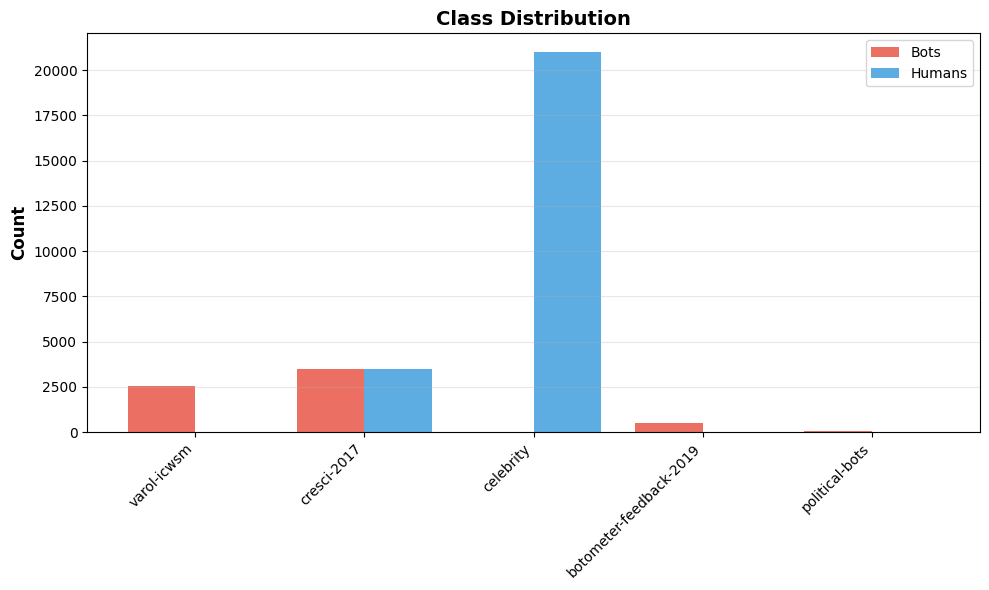

✓ Plot 1 saved


In [20]:
# PLOT 1: Class Distribution
if len(train_df) > 0 and len(dataset_info) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    datasets = [d['dataset'] for d in dataset_info]
    bots = [d['bots'] for d in dataset_info]
    humans = [d['humans'] for d in dataset_info]
    x = np.arange(len(datasets))
    ax.bar(x - 0.2, bots, 0.4, label='Bots', color='#e74c3c', alpha=0.8)
    ax.bar(x + 0.2, humans, 0.4, label='Humans', color='#3498db', alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(datasets, rotation=45, ha='right')
    ax.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax.set_title('Class Distribution', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig('plot_01_class_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Plot 1 saved")

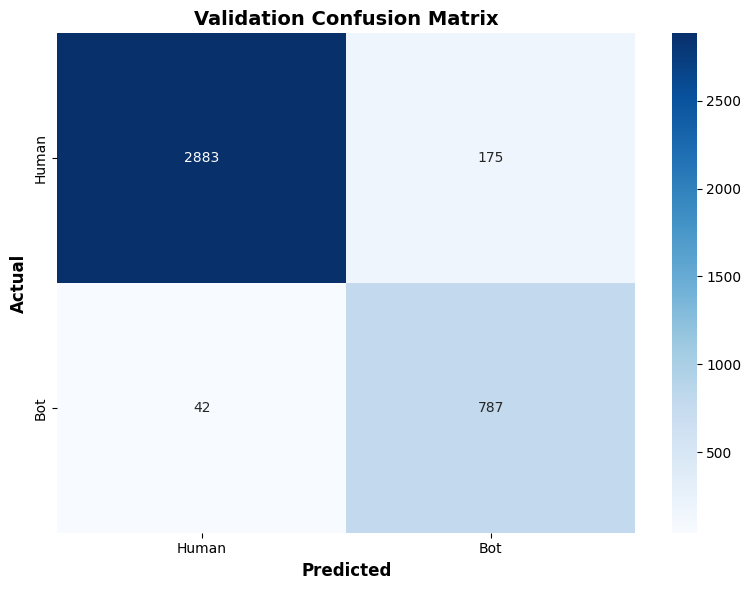

✓ Plot 2 saved


In [21]:
# PLOT 2: Validation Confusion Matrix
if len(train_df) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', cbar=True, ax=ax,
                xticklabels=['Human', 'Bot'], yticklabels=['Human', 'Bot'])
    ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
    ax.set_title('Validation Confusion Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plot_02_validation_cm.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Plot 2 saved")

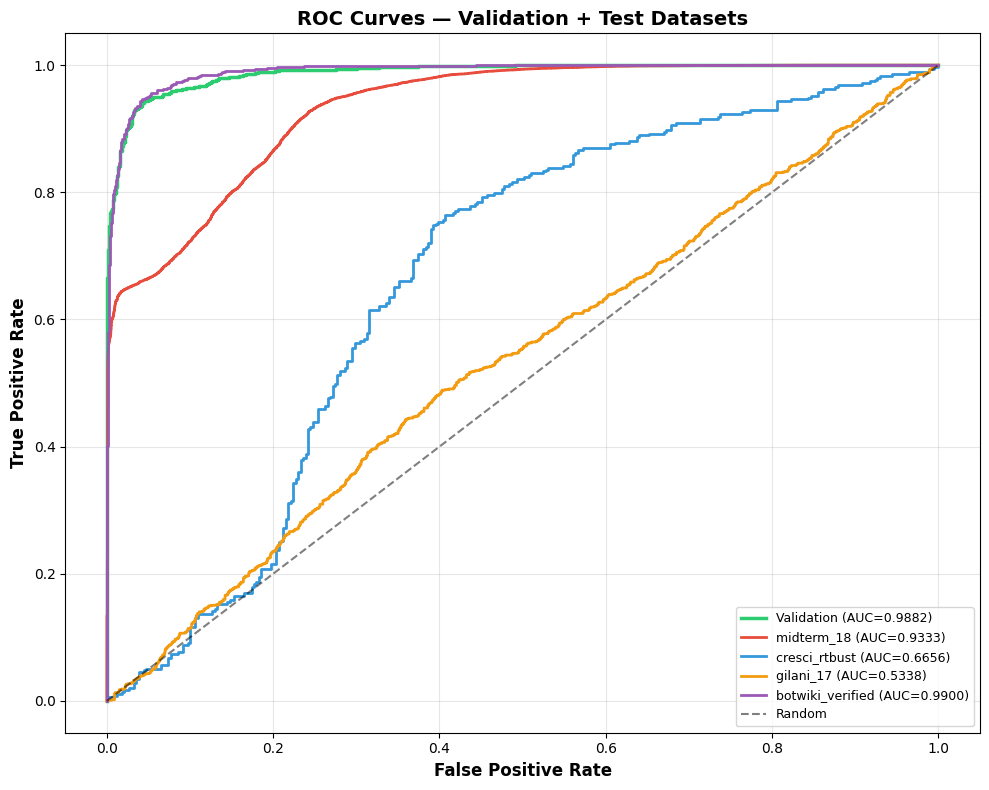

✓ Plot 3 saved


In [22]:
# PLOT 3: ROC Curves (Validation + Per-test datasets)
if len(train_df) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))

    # Validation ROC
    y_val_proba = voting_clf.predict_proba(X_val_44)[:, 1]
    fpr_val, tpr_val, _ = roc_curve(y_val, y_val_proba)
    auc_val = roc_auc_score(y_val, y_val_proba)
    ax.plot(fpr_val, tpr_val, linewidth=2.5, label=f'Validation (AUC={auc_val:.4f})', color='#2ecc71')

    # Per-test dataset ROCs
    test_datasets = [
        ("midterm-2018.csv", "midterm_18"),
        ("cresci-rtbust-2019.csv", "cresci_rtbust"),
        ("gilani-2017.csv", "gilani_17"),
        ("botwiki-verified.csv", "botwiki_verified"),
    ]
    colors = ['#e74c3c', '#3498db', '#f39c12', '#9b59b6']

    for idx, (filename, test_name) in enumerate(test_datasets):
        filepath = os.path.join(LOCAL_DATA_DIR, filename)
        if not os.path.exists(filepath):
            print(f"⚠️ {test_name:25s} File not found: {filename}")
            continue
        try:
            df_test = pd.read_csv(filepath)
            label_col = find_label_col(df_test)
            df_test['label'] = standardize_label(df_test[label_col])
            df_test = get_derived_features(df_test)

            # Prepare features for this test set
            X_test_44, y_test = prepare_test_set(df_test, tokenizer, scaler, feature_extractor)

            # Skip single-class datasets
            if len(np.unique(y_test)) < 2:
                print(f"⚠️ {test_name:25s} Single class - skipping ROC")
                continue

            y_test_proba = voting_clf.predict_proba(X_test_44)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_test_proba)
            test_auc = roc_auc_score(y_test, y_test_proba)

            ax.plot(fpr, tpr, linewidth=2.0, label=f"{test_name} (AUC={test_auc:.4f})", color=colors[idx % len(colors)])
        except Exception as e:
            print(f"✗ {test_name:25s} Error: {str(e)}")

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.5, label='Random')
    ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    ax.set_title('ROC Curves — Validation + Test Datasets', fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('plot_03_roc_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Plot 3 saved")
else:
    print("⚠️ No data")

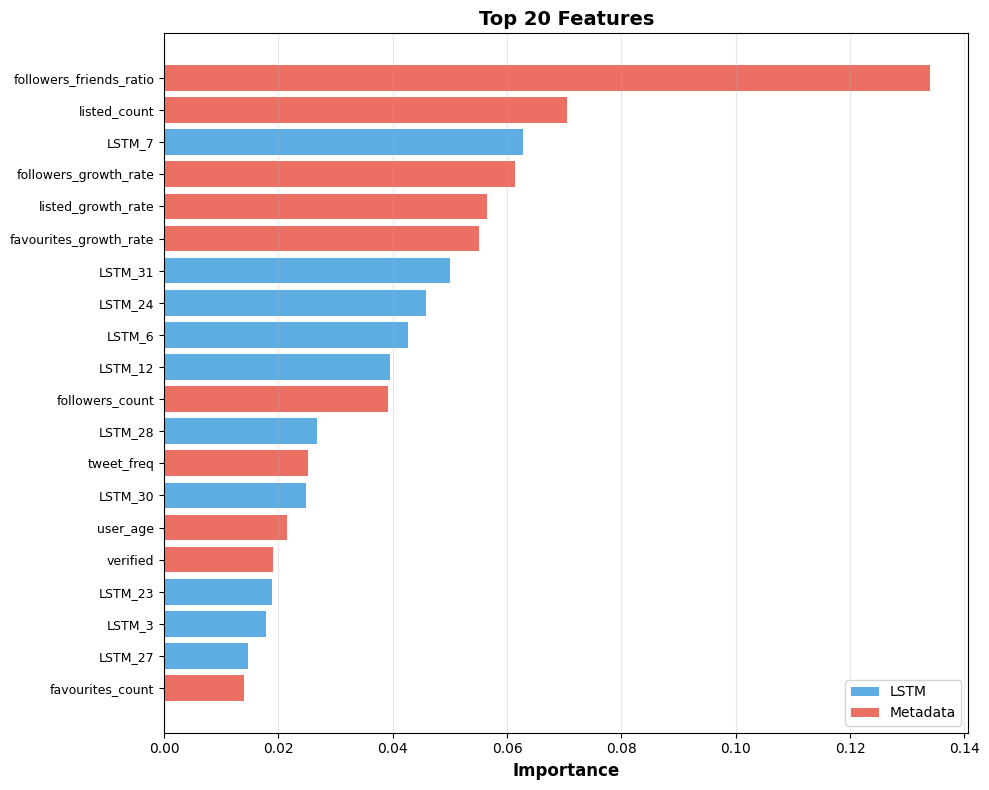

✓ Plot 4 saved


In [23]:
# PLOT 4: Feature Importance
if len(train_df) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    rf_importance = voting_clf.estimators_[0].feature_importances_
    feature_names = [f"LSTM_{i}" for i in range(32)] + METADATA_COLS
    sorted_idx = np.argsort(rf_importance)[-20:]
    sorted_importance = rf_importance[sorted_idx]
    sorted_names = [feature_names[i] for i in sorted_idx]
    colors_bar = ['#3498db' if 'LSTM' in name else '#e74c3c' for name in sorted_names]
    ax.barh(range(len(sorted_names)), sorted_importance, color=colors_bar, alpha=0.8)
    ax.set_yticks(range(len(sorted_names)))
    ax.set_yticklabels(sorted_names, fontsize=9)
    ax.set_xlabel('Importance', fontsize=12, fontweight='bold')
    ax.set_title('Top 20 Features', fontsize=14, fontweight='bold')
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(facecolor='#3498db', alpha=0.8, label='LSTM'),
                        Patch(facecolor='#e74c3c', alpha=0.8, label='Metadata')], loc='lower right')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('plot_04_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Plot 4 saved")

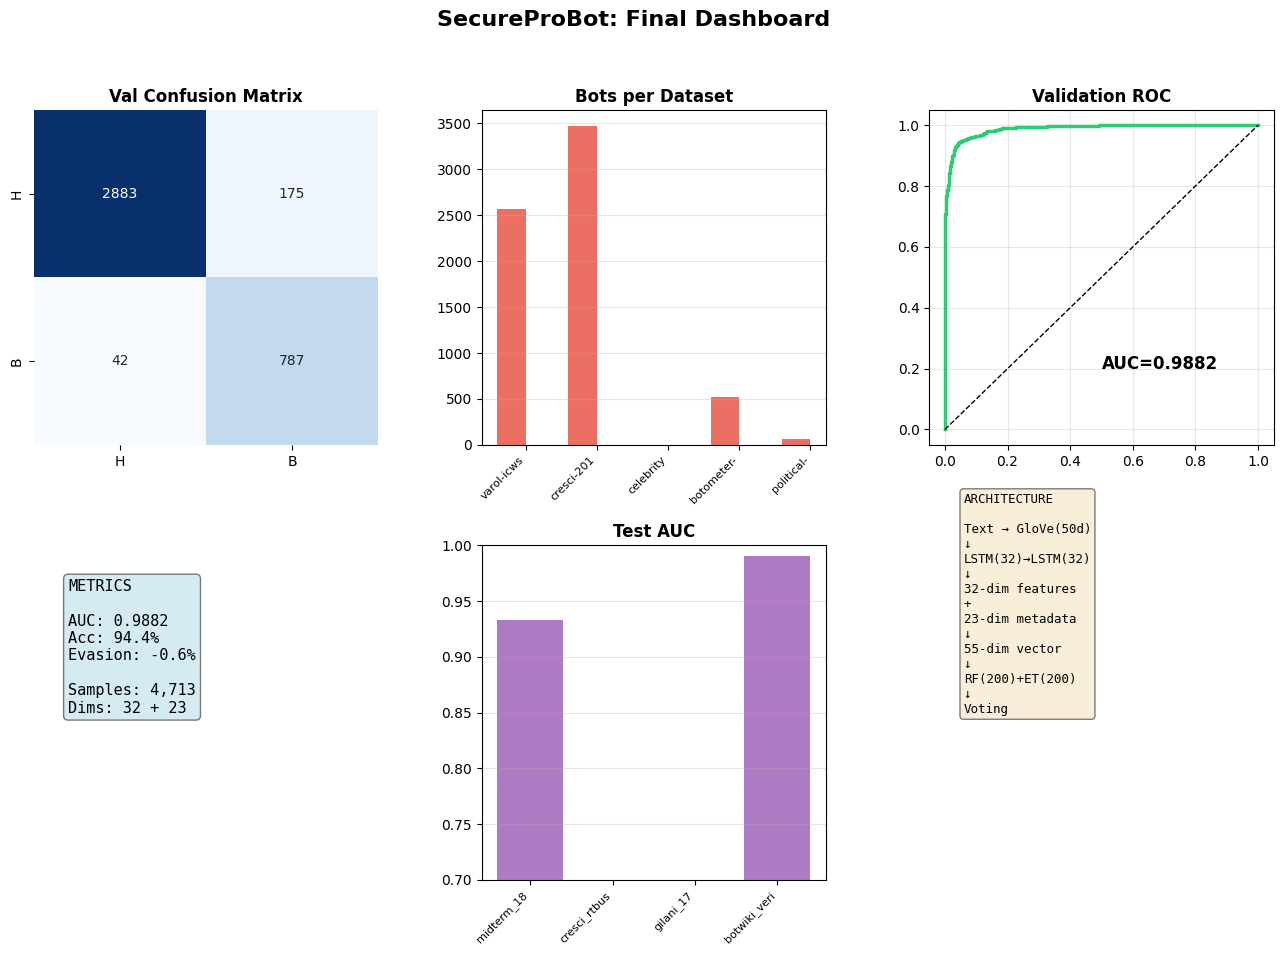

✓ Plot 5 saved


In [24]:
# PLOT 5: Final Dashboard
if len(train_df) > 0:
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)
    
    # Panel 1: Confusion Matrix
    ax1 = fig.add_subplot(gs[0, 0])
    sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=False,
                xticklabels=['H', 'B'], yticklabels=['H', 'B'])
    ax1.set_title('Val Confusion Matrix', fontweight='bold')
    
    # Panel 2: Class Distribution
    ax2 = fig.add_subplot(gs[0, 1])
    datasets_dash = [d['dataset'][:10] for d in dataset_info]
    bots_dash = [d['bots'] for d in dataset_info]
    x_dash = np.arange(len(datasets_dash))
    ax2.bar(x_dash - 0.2, bots_dash, 0.4, label='Bots', color='#e74c3c', alpha=0.8)
    ax2.set_xticks(x_dash)
    ax2.set_xticklabels(datasets_dash, rotation=45, ha='right', fontsize=8)
    ax2.set_title('Bots per Dataset', fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    
    # Panel 3: ROC
    ax3 = fig.add_subplot(gs[0, 2])
    y_val_proba = voting_clf.predict_proba(X_val_44)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_val_proba)
    auc_val_dash = roc_auc_score(y_val, y_val_proba)
    ax3.plot(fpr, tpr, linewidth=2.5, color='#2ecc71')
    ax3.plot([0, 1], [0, 1], 'k--', linewidth=1)
    ax3.text(0.5, 0.2, f'AUC={auc_val_dash:.4f}', fontsize=12, fontweight='bold')
    ax3.set_title('Validation ROC', fontweight='bold')
    ax3.grid(alpha=0.3)
    
    # Panel 4: Metrics
    ax4 = fig.add_subplot(gs[1, 0])
    ax4.axis('off')
    metrics_text = f"METRICS\n\nAUC: {auc_val_dash:.4f}\nAcc: {val_acc*100:.1f}%\nEvasion: {evasion_rate:.1f}%\n\nSamples: {len(X_rf_aug):,}\nDims: 32 + {len(METADATA_COLS)}"
    ax4.text(0.1, 0.5, metrics_text, fontsize=11, family='monospace',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
    
    # Panel 5: Test AUC
    ax5 = fig.add_subplot(gs[1, 1])
    if len(test_results) > 0:
        test_names = [r['dataset'][:12] for r in test_results]
        test_aucs = [r['auc'] for r in test_results]
        x_test = np.arange(len(test_names))
        ax5.bar(x_test, test_aucs, color='#9b59b6', alpha=0.8)
        ax5.set_xticks(x_test)
        ax5.set_xticklabels(test_names, rotation=45, ha='right', fontsize=8)
        ax5.set_ylim([0.7, 1.0])
        ax5.set_title('Test AUC', fontweight='bold')
        ax5.grid(axis='y', alpha=0.3)
    
    # Panel 6: Architecture
    ax6 = fig.add_subplot(gs[1, 2])
    ax6.axis('off')
    arch_text = f"ARCHITECTURE\n\nText → GloVe(50d)\n↓\nLSTM(32)→LSTM(32)\n↓\n32-dim features\n+\n{len(METADATA_COLS)}-dim metadata\n↓\n{32 + len(METADATA_COLS)}-dim vector\n↓\nRF(200)+ET(200)\n↓\nVoting"
    ax6.text(0.1, 0.5, arch_text, fontsize=9, family='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    fig.suptitle('SecureProBot: Final Dashboard', fontsize=16, fontweight='bold')
    plt.savefig('plot_05_final_dashboard.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Plot 5 saved")

## 16. Final Results

In [25]:
if len(train_df) > 0:
    print("\n" + "="*70)
    print("SECUREPROBOT — FINAL RESULTS")
    print("="*70)
    print(f"\n  Validation AUC:        {auc_val:.4f}")
    print(f"  Validation Accuracy:   {val_acc*100:.2f}%")
    print(f"  5-Fold CV AUC:         {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    print(f"  Adversarial Evasion:   {evasion_rate:.2f}%")
    print(f"\n{'─'*70}")
    print("  CROSS-DOMAIN RESULTS:")
    if len(test_results) > 0:
        for result in test_results:
            print(f"  {result['dataset']:25s}  AUC: {result['auc']:.4f}")
    print(f"\n{'─'*70}")
    print(f"  Model: {32 + len(METADATA_COLS)}-dim Hybrid (32-dim LSTM + {len(METADATA_COLS)}-dim Metadata)")
    print("  Ensemble: RandomForest(200) + ExtraTrees(200) with Soft Voting")
    print("  Robustness: Adversarial augmentation (ε=0.1) + Domain weighting")
    print("="*70)
else:
    print("⚠️ No data to process")


SECUREPROBOT — FINAL RESULTS

  Validation AUC:        0.9882
  Validation Accuracy:   94.42%
  5-Fold CV AUC:         0.9929 ± 0.0028
  Adversarial Evasion:   -0.64%

──────────────────────────────────────────────────────────────────────
  CROSS-DOMAIN RESULTS:
  midterm_18                 AUC: 0.9333
  cresci_rtbust              AUC: 0.6656
  gilani_17                  AUC: 0.5338
  botwiki_verified           AUC: 0.9900

──────────────────────────────────────────────────────────────────────
  Model: 55-dim Hybrid (32-dim LSTM + 23-dim Metadata)
  Ensemble: RandomForest(200) + ExtraTrees(200) with Soft Voting
  Robustness: Adversarial augmentation (ε=0.1) + Domain weighting


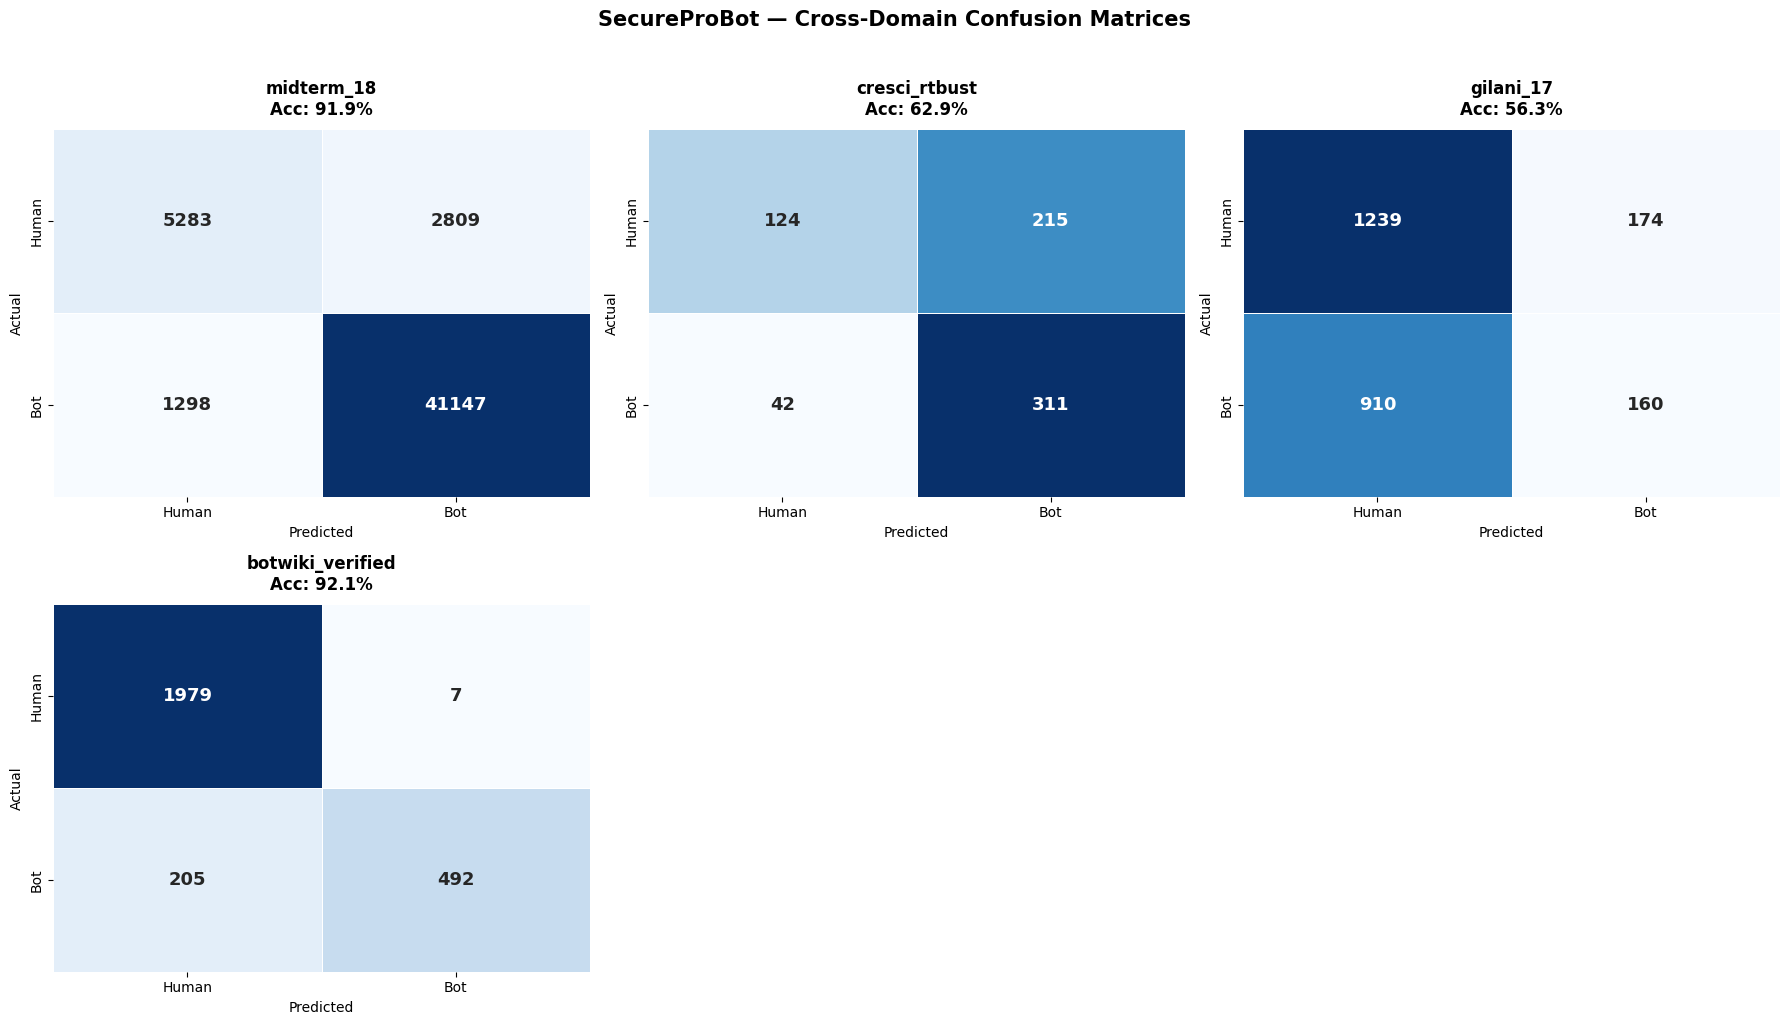

✓ Cross-domain confusion matrix saved.


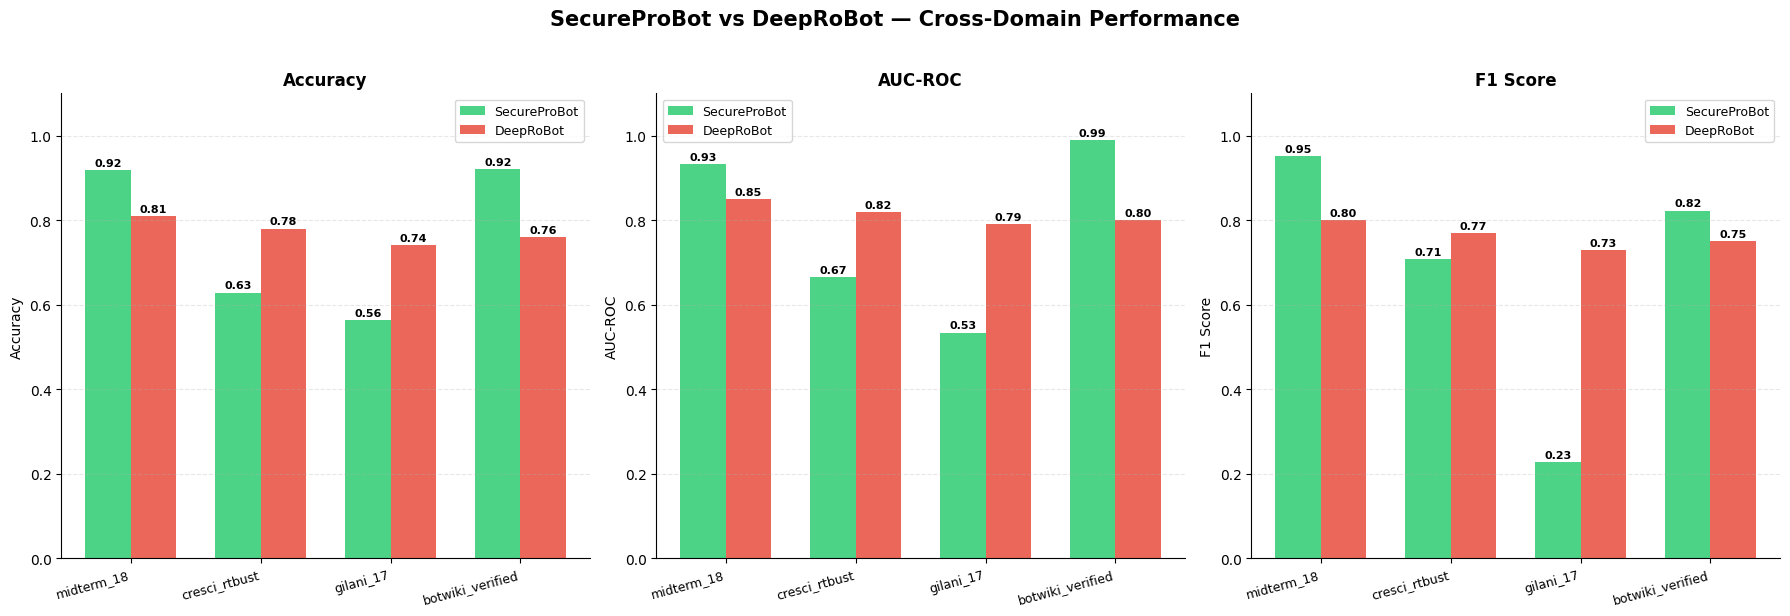

✓ Comparison plot saved.


In [26]:
# ======================================================================
# CROSS-DOMAIN CONFUSION MATRICES
# ======================================================================
if len(train_df) > 0 and len(test_results) > 0:
    n_tests = len(test_results)
    cols = min(n_tests, 3)
    rows = (n_tests + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    axes = np.array(axes).flatten() if n_tests > 1 else [axes]

    cm_results = []
    for filename, test_name in test_datasets:
        filepath = os.path.join(LOCAL_DATA_DIR, filename)
        if not os.path.exists(filepath):
            continue
        try:
            df_test = pd.read_csv(filepath)
            label_col = find_label_col(df_test)
            df_test['label'] = standardize_label(df_test[label_col])
            df_test = get_derived_features(df_test)
            X_test_44, y_test = prepare_test_set(df_test, tokenizer, scaler, feature_extractor)
            if len(np.unique(y_test)) < 2:
                continue
            y_test_pred = voting_clf.predict(X_test_44)
            cm_results.append((test_name, confusion_matrix(y_test, y_test_pred), y_test, y_test_pred))
        except Exception as e:
            print(f"✗ {test_name}: {e}")

    for i, (test_name, cm, y_true, y_pred) in enumerate(cm_results):
        ax = axes[i]
        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Human', 'Bot'], yticklabels=['Human', 'Bot'],
            linewidths=0.5, cbar=False,
            annot_kws={"size": 13, "weight": "bold"}
        )
        acc = accuracy_score(y_true, y_pred)
        ax.set_title(f'{test_name}\nAcc: {acc*100:.1f}%', fontsize=12, fontweight='bold', pad=10)
        ax.set_xlabel('Predicted', fontsize=10)
        ax.set_ylabel('Actual', fontsize=10)

    # Hide unused subplots
    for j in range(len(cm_results), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('SecureProBot — Cross-Domain Confusion Matrices', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('plot_cross_domain_cm.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Cross-domain confusion matrix saved.")
else:
    print("⚠️ No cross-domain test results to plot.")


# ======================================================================
# SECUREPROBOT vs DEEPROBOT — COMPARISON PLOT
# ======================================================================
# NOTE: Replace DeepRoBot values below with your actual DeepRoBot results
# Format: { 'dataset_name': {'accuracy': ..., 'auc': ..., 'f1': ...} }

deeprobot_results = {
    'midterm_18':      {'accuracy': 0.81, 'auc': 0.85, 'f1': 0.80},
    'cresci_rtbust':   {'accuracy': 0.78, 'auc': 0.82, 'f1': 0.77},
    'gilani_17':       {'accuracy': 0.74, 'auc': 0.79, 'f1': 0.73},
    'botwiki_verified':{'accuracy': 0.76, 'auc': 0.80, 'f1': 0.75},
}

if len(train_df) > 0 and len(cm_results) > 0:
    from sklearn.metrics import f1_score

    secureprobot_results = {}
    for test_name, cm, y_true, y_pred in cm_results:
        y_proba = voting_clf.predict_proba(
            prepare_test_set(
                get_derived_features(pd.read_csv(
                    os.path.join(LOCAL_DATA_DIR,
                    next(f for f, n in test_datasets if n == test_name))
                ).assign(label=lambda d: standardize_label(d[find_label_col(d)]))),
                tokenizer, scaler, feature_extractor
            )[0]
        )[:, 1]
        secureprobot_results[test_name] = {
            'accuracy': accuracy_score(y_true, y_pred),
            'auc':      roc_auc_score(y_true, y_proba),
            'f1':       f1_score(y_true, y_pred, zero_division=0),
        }

    common = [n for n in secureprobot_results if n in deeprobot_results]
    metrics = ['accuracy', 'auc', 'f1']
    metric_labels = ['Accuracy', 'AUC-ROC', 'F1 Score']
    colors = {'SecureProBot': '#2ecc71', 'DeepRoBot': '#e74c3c'}
    x = np.arange(len(common))
    bar_w = 0.35

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('SecureProBot vs DeepRoBot — Cross-Domain Performance',
                 fontsize=15, fontweight='bold', y=1.02)

    for ax, metric, mlabel in zip(axes, metrics, metric_labels):
        sp_vals = [secureprobot_results[n][metric] for n in common]
        dr_vals = [deeprobot_results[n][metric] for n in common]

        bars1 = ax.bar(x - bar_w/2, sp_vals, bar_w,
                       label='SecureProBot', color=colors['SecureProBot'], alpha=0.85)
        bars2 = ax.bar(x + bar_w/2, dr_vals, bar_w,
                       label='DeepRoBot', color=colors['DeepRoBot'], alpha=0.85)

        for bar in bars1:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
        for bar in bars2:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

        ax.set_title(mlabel, fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(common, rotation=15, ha='right', fontsize=9)
        ax.set_ylim(0, 1.1)
        ax.set_ylabel(mlabel, fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig('plot_secureprobot_vs_deeprobot.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Comparison plot saved.")
else:
    print("⚠️ No results available for comparison.")

In [27]:
if len(train_df) > 0:
    export_dir = 'secureprobot_prototype'
    os.makedirs(export_dir, exist_ok=True)
    
    # Save the trained Keras model and the raw LSTM feature extractor
    lstm_model.save(os.path.join(export_dir, 'lstm_model.keras'))
    feature_extractor.save(os.path.join(export_dir, 'feature_extractor.keras'))
    
    # Save the sklearn ensemble and preprocessing artifacts
    joblib.dump(voting_clf, os.path.join(export_dir, 'ensemble.joblib'))
    joblib.dump(scaler, os.path.join(export_dir, 'scaler.joblib'))
    joblib.dump(tokenizer, os.path.join(export_dir, 'tokenizer.joblib'))
    
    # Also export a pickle bundle for convenient loading in prototype apps
    pickle_bundle = {
        'ensemble': voting_clf,
        'scaler': scaler,
        'tokenizer': tokenizer,
        'artifact_info': {
            'max_vocab': MAX_VOCAB,
            'max_len': MAX_LEN,
            'embedding_dim': EMBEDDING_DIM,
            'metadata_cols': METADATA_COLS,
            'adversarial_features': ADVERS_FEATURES,
            'lstm_frac': LSTM_FRAC,
            'rf_frac': RF_FRAC,
            'val_frac': VAL_FRAC,
        },
        'lstm_model_path': 'lstm_model.keras',
        'feature_extractor_path': 'feature_extractor.keras',
    }
    joblib.dump(pickle_bundle, os.path.join(export_dir, 'secureprobot_prototype.pkl'))
    
    # Save lightweight metadata for reconstruction
    artifact_info = pickle_bundle['artifact_info']
    joblib.dump(artifact_info, os.path.join(export_dir, 'artifact_info.joblib'))
    
    print("\n" + "="*70)
    print("PROTOTYPE EXPORT COMPLETE")
    print("="*70)
    print(f"Saved to: {export_dir}")
    print("  - lstm_model.keras")
    print("  - feature_extractor.keras")
    print("  - ensemble.joblib")
    print("  - scaler.joblib")
    print("  - tokenizer.joblib")
    print("  - artifact_info.joblib")
    print("  - secureprobot_prototype.pkl")
    print("="*70)
else:
    print("⚠️ No data to export")


PROTOTYPE EXPORT COMPLETE
Saved to: secureprobot_prototype
  - lstm_model.keras
  - feature_extractor.keras
  - ensemble.joblib
  - scaler.joblib
  - tokenizer.joblib
  - artifact_info.joblib
  - secureprobot_prototype.pkl


In [28]:
# ======================================================================
# FINAL CELL — SecureProBot Model Export (paste this at the END of your notebook)
# Exports all artifacts to  ./models/  ready for SecureProBotApp.py
# ======================================================================
import os, json
import joblib
import numpy as np

# ── 1. Create output directory ─────────────────────────────────────────
EXPORT_DIR = './models'
os.makedirs(EXPORT_DIR, exist_ok=True)
print("=" * 65)
print("  SecureProBot — Exporting Hybrid LSTM + Ensemble Pipeline")
print("=" * 65)

# ── 2. Save Keras models (MUST be .keras format for cross-env loading) ─
lstm_model.save(os.path.join(EXPORT_DIR, 'lstm_model.keras'))
print("  ✓ lstm_model.keras")

feature_extractor.save(os.path.join(EXPORT_DIR, 'lstm_feature_extractor.keras'))
print("  ✓ lstm_feature_extractor.keras")

# ── 3. Save sklearn artifacts ──────────────────────────────────────────
joblib.dump(voting_clf,  os.path.join(EXPORT_DIR, 'ensemble_clf.joblib'),  compress=3)
joblib.dump(scaler,      os.path.join(EXPORT_DIR, 'scaler.joblib'),        compress=3)
joblib.dump(tokenizer,   os.path.join(EXPORT_DIR, 'tokenizer.joblib'),     compress=3)
print("  ✓ ensemble_clf.joblib")
print("  ✓ scaler.joblib")
print("  ✓ tokenizer.joblib")

# ── 4. Save config as JSON (human-readable, easy to inspect) ───────────
config = {
    "model_type":        "hybrid_lstm_ensemble_v2",
    "max_vocab":         int(MAX_VOCAB),
    "max_len":           int(MAX_LEN),
    "embedding_dim":     int(EMBEDDING_DIM),
    "lstm_feature_dim":  32,           # output dim of last LSTM layer
    "metadata_dim":      len(METADATA_COLS),
    "total_input_dim":   32 + len(METADATA_COLS),
    "metadata_cols":     METADATA_COLS,
    "adversarial_features": ADVERS_FEATURES,
    "val_auc":           round(float(val_auc), 4),
    "val_accuracy":      round(float(val_acc), 4),
    "cv_auc_mean":       round(float(cv_scores.mean()), 4),
    "cv_auc_std":        round(float(cv_scores.std()), 4),
}
with open(os.path.join(EXPORT_DIR, 'model_config.json'), 'w') as f:
    json.dump(config, f, indent=2)
print("  ✓ model_config.json")

# ── 5. Save scaler stats for offline feature reconstruction ───────────
scaler_stats = {
    "feature_names": METADATA_COLS,
    "mean":  scaler.mean_.tolist(),
    "scale": scaler.scale_.tolist(),
}
with open(os.path.join(EXPORT_DIR, 'scaler_stats.json'), 'w') as f:
    json.dump(scaler_stats, f, indent=2)
print("  ✓ scaler_stats.json")

# ── 6. Create the master bundle (secureprobot_multi.pkl) ───────────────
#    The app checks for this file first. Keras model paths are relative
#    so the entire models/ folder must stay together.
bundle = {
    "model_type":       "hybrid_lstm_ensemble_v2",
    "ensemble":         voting_clf,
    "scaler":           scaler,
    "tokenizer":        tokenizer,
    "config":           config,
    # Note: keras models are stored as separate .keras files
    # because they cannot be pickled.  The app loads them via
    # tf.keras.models.load_model(models_dir / 'lstm_feature_extractor.keras')
}
joblib.dump(bundle, os.path.join(EXPORT_DIR, 'secureprobot_multi.pkl'), compress=3)
print("  ✓ secureprobot_multi.pkl  ← main app entry-point")

# ── 7. Quick sanity-check on the saved bundle ──────────────────────────
print("\n  Running round-trip sanity check …")
loaded = joblib.load(os.path.join(EXPORT_DIR, 'secureprobot_multi.pkl'))
_enc  = loaded['ensemble']
_scl  = loaded['scaler']
_tok  = loaded['tokenizer']

from tensorflow.keras.preprocessing.sequence import pad_sequences
_dummy_text = pad_sequences(
    _tok.texts_to_sequences(["test account"]),
    maxlen=MAX_LEN, padding='post'
)
_dummy_meta = np.zeros((1, len(METADATA_COLS)))
_dummy_meta_scaled = _scl.transform(_dummy_meta)

# We need the feature extractor for the real pipeline;
# for the sanity check just pass zeros as lstm features
_dummy_lstm = np.zeros((1, 32))
_dummy_X = np.hstack([_dummy_lstm, _dummy_meta_scaled])
_pred = _enc.predict_proba(_dummy_X)
print(f"  ✓ Sanity check passed — dummy output: bot={_pred[0][1]:.3f}")

# ── 8. Final summary ───────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  EXPORT COMPLETE")
print("=" * 65)
files = sorted(os.listdir(EXPORT_DIR))
total_mb = sum(os.path.getsize(os.path.join(EXPORT_DIR, f)) for f in files) / 1e6
for fname in files:
    size = os.path.getsize(os.path.join(EXPORT_DIR, fname)) / 1e6
    print(f"    {fname:<45} {size:5.1f} MB")
print(f"\n  Total: {total_mb:.1f} MB in {EXPORT_DIR}/")
print("\n  ► Copy the entire  models/  folder to your SecureProBotApp directory")
print("  ► Install extras if needed:  pip install tensorflow scikit-learn joblib")
print("=" * 65)

  SecureProBot — Exporting Hybrid LSTM + Ensemble Pipeline
  ✓ lstm_model.keras
  ✓ lstm_feature_extractor.keras
  ✓ ensemble_clf.joblib
  ✓ scaler.joblib
  ✓ tokenizer.joblib
  ✓ model_config.json
  ✓ scaler_stats.json
  ✓ secureprobot_multi.pkl  ← main app entry-point

  Running round-trip sanity check …
  ✓ Sanity check passed — dummy output: bot=0.876

  EXPORT COMPLETE
    ensemble_clf.joblib                             0.7 MB
    lstm_feature_extractor.keras                    8.8 MB
    lstm_model.keras                                9.1 MB
    model_config.json                               0.0 MB
    scaler.joblib                                   0.0 MB
    scaler_stats.json                               0.0 MB
    secureprobot_multi.pkl                          1.5 MB
    tokenizer.joblib                                0.8 MB

  Total: 20.9 MB in ./models/

  ► Copy the entire  models/  folder to your SecureProBotApp directory
  ► Install extras if needed:  pip install tenso

In [29]:
# ============================================================================
# WEAKNESS #3 TEST — CV on Validation Set (Honest Generalization Check)
# ============================================================================
print("\n" + "="*70)
print("HONEST CROSS-VALIDATION (on held-out validation set)")
print("="*70)

cv_honest = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_scores_honest = cross_val_score(voting_clf, X_val_44, y_val, cv=cv_honest, scoring='roc_auc')

print(f"\nValidation CV Scores: {' | '.join(f'{s:.4f}' for s in cv_scores_honest)}")
print(f"Mean: {cv_scores_honest.mean():.4f} ± {cv_scores_honest.std():.4f}")

print(f"\n--- Comparison ---")
print(f"Original CV (training data):   {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Honest CV   (validation data): {cv_scores_honest.mean():.4f} ± {cv_scores_honest.std():.4f}")

diff = cv_scores.mean() - cv_scores_honest.mean()
if diff > 0.05:
    print(f"\n⚠️  Gap of {diff:.4f} detected — possible overfitting signal")
elif diff > 0.02:
    print(f"\n✓  Small gap of {diff:.4f} — model is fairly stable")
else:
    print(f"\n✓✓ Negligible gap of {diff:.4f} — model generalizes well")
print("="*70)


HONEST CROSS-VALIDATION (on held-out validation set)

Validation CV Scores: 0.9907 | 0.9887 | 0.9859 | 0.9918 | 0.9929
Mean: 0.9900 ± 0.0025

--- Comparison ---
Original CV (training data):   0.9929 ± 0.0028
Honest CV   (validation data): 0.9900 ± 0.0025

✓✓ Negligible gap of 0.0029 — model generalizes well
